# Assignment 2 2AMM10 2023-2024

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

In [1]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [3]:
!pip show torch

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


In [4]:
!pip install rdkit
!pip install torch_geometric
!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 33.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 65.3 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 95.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 71.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 112.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 62.9 MB/s eta 0:00:00


In [5]:
import pickle
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt

In [15]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [6]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [16]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


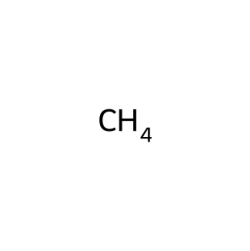

In [8]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │     0.135│     1.446│     0.410
  C  │  6   │     0.051│    -0.047│     0.030
  C  │  6   │     0.960│    -0.898│     0.926
  C  │  6   │    -1.398│    -0.525│     0.167
  O  │  8   │    -1.791│    -1.082│     1.169
  N  │  7   │    -2.311│    -0.287│    -0.876
  C  │  6   │    -3.688│    -0.744│    -0.656
  C  │  6   │    -2.012│     0.348│    -2.073
  O  │  8   │    -2.812│     0.548│    -2.956
  H  │  1   │     1.170│     1.792│     0.342
  H  │  1   │    -0.476│     2.078│    -0.242
  H  │  1   │    -0.206│     1.594│     1.439
  H  │  1   │     0.385│    -0.167│    -1.005
  H  │  1   │     0.652│    -0.821│     1.971
  H  │  1   │     0.920│    -1.954│     0.646
  H  │  1   │     1.995│    -0.556│     0.836
  H  │  1   │    -4.104│    -0.260│     0.230
  H  │  1   │    -4.264│    -0.484│    -1.541
  H  │  1   │    -3.701│    -1.823│    -0.491
  H  │  1   │    -0.962│     0.660

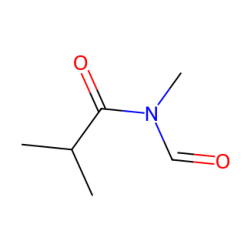

In [9]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

## Task 1

In [13]:
! pip install deepchem
from deepchem.feat.smiles_tokenizer import BasicSmilesTokenizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.9 MB/s eta 0:00:00


wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [10]:
from collections import Counter
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import math
from tqdm import tqdm

In [12]:
tokenizer = BasicSmilesTokenizer()
counter = Counter()
for s in smiles_data:
  counter.update(tokenizer.tokenize(s))

vocab = {}
for k, v in counter.items():
  vocab[k] = len(vocab) + 1
vocab['<pad>'] = 0
vocab['<unk>'] = len(vocab)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SMILESDataset(Dataset):
  def __init__(self, smiles_data, fe, vocab):
    self.smiles_data = smiles_data
    self.fe = fe
    self.vocab = vocab
    tokenizer = BasicSmilesTokenizer()
    self.tokenized_smiles = [tokenizer.tokenize(s) for s in smiles_data]

  def __len__(self):
    return len(self.smiles_data)

  def __getitem__(self, idx):
    int_smiles = [vocab.get(token, vocab['<unk>']) for token in self.tokenized_smiles[idx]]
    return int_smiles, self.fe[idx]

def collate_fn(batch):
    label_list, smiles_list = [], []
    for (_smiles, _label) in batch:
      smiles_list.append(torch.tensor(_smiles, dtype=torch.int64))
      label_list.append(_label)

    smiles_batch = pad_sequence(smiles_list, batch_first=True, padding_value=0)
    label_batch = torch.tensor(label_list, dtype=torch.float32)

    return smiles_batch.to(device), label_batch.to(device)


In [ ]:
class RNNRegressionModel(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers):
    super(RNNRegressionModel, self).__init__()
    self.num_layers = num_layers
    self.embeddings = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
    self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
    self.fc1 = nn.Linear(hidden_dim, hidden_dim)
    self.fc2 = nn.Linear(hidden_dim, 1)
    self.drop = nn.Dropout(0.5)
    self.criterion = nn.MSELoss()
    # self.optimizer = torch.optim.Adam(self.parameters())

  def forward(self, x):
    x = self.embeddings(x)
    out, (hidden, _) = self.rnn(x)
    last_timestep = out[:, -1]
    last_timestep = self.drop(last_timestep)
    h = self.fc1(last_timestep)
    h = self.drop(h)
    h = nn.ReLU()(h)
    y_pred = self.fc2(h).squeeze(1)
    return y_pred

In [ ]:
def mse(y_true, y_pred):
  return torch.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
  ss_res = torch.sum((y_true - y_pred) ** 2)
  ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
  return 1 - (ss_res / ss_tot)

In [ ]:
def train(model, dataloader):
  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
  y_true_list, y_pred_list = [], []
  for x_batch, y_true in dataloader:
    optimizer.zero_grad()
    y_pred = model(x_batch)
    loss = model.criterion(y_pred, y_true)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
    optimizer.step()
    y_true_list.append(y_true.cpu())
    y_pred_list.append(y_pred.cpu())

  y_true = torch.cat(y_true_list)
  y_pred = torch.cat(y_pred_list)

  return mse(y_true, y_pred)

def evaluate(model, dataloader):
  model.eval()
  y_true_list, y_pred_list = [], []
  with torch.no_grad():
    for x_batch, y_true in dataloader:
      y_pred = model(x_batch)
      loss = model.criterion(y_pred, y_true)
      y_true_list.append(y_true.cpu())
      y_pred_list.append(y_pred.cpu())

  y_true = torch.cat(y_true_list)
  y_pred = torch.cat(y_pred_list)

  return mse(y_true, y_pred), r2_score(y_true, y_pred)

In [ ]:
def split_train_val_set(data_list, label_list, idx, vocab, val_ratio=0.1):
  """
  Construct training set and validation set.
  """
  dataset_size = len(idx)
  val_size = int(np.floor(val_ratio * dataset_size))
  shuffed_idx = np.random.permutation(idx)
  x_train = [data_list[i] for i in shuffed_idx[:-val_size]]
  x_val = [data_list[i] for i in shuffed_idx[-val_size:]]
  y_train = [label_list[i] for i in shuffed_idx[:-val_size]]
  y_val = [label_list[i] for i in shuffed_idx[-val_size:]]
  train_set = SMILESDataset(x_train, y_train, vocab)
  val_set = SMILESDataset(x_val, y_val, vocab)

  return train_set, val_set


In [ ]:
model = RNNRegressionModel(len(vocab), embed_dim=512, hidden_dim=128, num_layers=2).to(device)
batch_size = 128
epochs = 10

# Training loop
original_fe = fe * std + mu

for epoch in tqdm(range(epochs)):
  train_loss, val_loss = 0, 0
  train_set, val_set = split_train_val_set(smiles_data, original_fe, train_idxes, vocab)
  train_dl = DataLoader(train_set, batch_size=batch_size, collate_fn=collate_fn)
  val_dl = DataLoader(val_set, batch_size=batch_size, collate_fn=collate_fn)

  train_loss = train(model, train_dl)
  val_loss, r2 = evaluate(model, val_dl)

  # print the results
  print(
    f'EPOCH: {epoch+1:0>{len(str(epochs))}}/{epochs}',
    end=' '
  )
  print(f'LOSS: {train_loss:.4f}',end=' ')
  print(f'VAL-LOSS: {val_loss:.4f}  VAL-R squared score: {r2:.4f}',end='\n')

 10%|█         | 1/10 [00:05<00:49,  5.53s/it]

EPOCH: 01/10 LOSS: 2362.9724 VAL-LOSS: 111.2844  VAL-R squared score: -0.0257


 20%|██        | 2/10 [00:11<00:48,  6.04s/it]

EPOCH: 02/10 LOSS: 161.2312 VAL-LOSS: 21.2198  VAL-R squared score: 0.7978


 30%|███       | 3/10 [00:17<00:40,  5.75s/it]

...

EPOCH: 08/10 LOSS: 118.7877 VAL-LOSS: 6.6382  VAL-R squared score: 0.9382


 90%|█████████ | 9/10 [00:53<00:05,  5.88s/it]

EPOCH: 09/10 LOSS: 116.4368 VAL-LOSS: 9.1941  VAL-R squared score: 0.9139


100%|██████████| 10/10 [00:59<00:00,  5.92s/it]

EPOCH: 10/10 LOSS: 116.5545 VAL-LOSS: 5.3339  VAL-R squared score: 0.9495


In [ ]:
# Construct test dataloader
smiles_test = [smiles_data[i] for i in test_idxes]
fe_test = [original_fe[i] for i in test_idxes]
test_set = SMILESDataset(smiles_test, fe_test, vocab)
test_dl = DataLoader(test_set, batch_size=batch_size, collate_fn=collate_fn)

# Evaluate model on test set
test_loss, r2 = evaluate(model, test_dl)
print(f'TEST-LOSS: {test_loss:.4f}  TEST-R squared score: {r2:.4f}')

TEST-LOSS: 6.0651  TEST-R squared score: 0.9435


In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': model.optimizer.state_dict(),
}, 'RNN_all_checkpoint.pth')

## Task 2

In [ ]:
def train_on_subset(model, subset_size, batch_size=128, epochs=10):
  for epoch in tqdm(range(epochs)):
    train_loss, val_loss = 0, 0
    train_set, val_set = split_train_val_set(smiles_data, original_fe, train_idxes[:subset_size], vocab)
    train_dl = DataLoader(train_set, batch_size=batch_size, collate_fn=collate_fn)
    val_dl = DataLoader(val_set, batch_size=batch_size, collate_fn=collate_fn)

    train_loss = train(model, train_dl)
    val_loss, r2 = evaluate(model, val_dl)

    # print the results
    print(
      f'EPOCH: {epoch+1:0>{len(str(epochs))}}/{epochs}',
      end=' '
    )
    print(f'LOSS: {train_loss:.4f}',end=' ')
    print(f'VAL-LOSS: {val_loss:.4f}  VAL-R squared score: {r2:.4f}',end='\n')


In [ ]:
# Train models on subsets of differnt size
subset_sizes = [100,300,1000,3000,10000]
models = []

for subset_size in subset_sizes:
  print(f"== Training on subset of size {subset_size} ==", end='\n')
  model = RNNRegressionModel(len(vocab), embed_dim=512, hidden_dim=128, num_layers=2).to(device)
  train_on_subset(model, subset_size)
  models.append(model)


== Training on subset of size 100 ==


100%|██████████| 10/10 [00:00<00:00, 97.00it/s]


EPOCH: 01/10 LOSS: 5929.7402 VAL-LOSS: 5842.5967  VAL-R squared score: -46.8136
EPOCH: 02/10 LOSS: 5836.1279 VAL-LOSS: 6678.8975  VAL-R squared score: -30.8992
EPOCH: 03/10 LOSS: 6013.6992 VAL-LOSS: 5073.6670  VAL-R squared score: -30.9789
EPOCH: 04/10 LOSS: 5991.1387 VAL-LOSS: 5263.6191  VAL-R squared score: -26.3703
EPOCH: 05/10 LOSS: 5823.6279 VAL-LOSS: 6761.7798  VAL-R squared score: -59.3331
EPOCH: 06/10 LOSS: 5820.6846 VAL-LOSS: 6782.6328  VAL-R squared score: -64.5410
EPOCH: 07/10 LOSS: 5828.7349 VAL-LOSS: 6701.2109  VAL-R squared score: -67.2445
EPOCH: 08/10 LOSS: 5962.9824 VAL-LOSS: 5485.2085  VAL-R squared score: -31.1624
EPOCH: 09/10 LOSS: 6016.9395 VAL-LOSS: 4984.9131  VAL-R squared score: -35.2918
EPOCH: 10/10 LOSS: 5900.2749 VAL-LOSS: 6031.5537  VAL-R squared score: -34.9048
== Training on subset of size 300 ==


  0%|          | 0/10 [00:00<?, ?it/s]

EPOCH: 01/10 LOSS: 5900.8110 VAL-LOSS: 5536.0791  VAL-R squared score: -47.1732
EPOCH: 02/10 LOSS: 5887.6963 VAL-LOSS: 5628.2998  VAL-R squared score: -41.0188
EPOCH: 03/10 LOSS: 5817.5742 VAL-LOSS: 6247.4077  VAL-R squared score: -44.8036


...

EPOCH: 08/10 LOSS: 913.9988 VAL-LOSS: 603.0749  VAL-R squared score: -4.1913


 90%|█████████ | 9/10 [00:04<00:00,  1.86it/s]

EPOCH: 09/10 LOSS: 488.7712 VAL-LOSS: 223.3602  VAL-R squared score: -1.1439


100%|██████████| 10/10 [00:05<00:00,  1.95it/s]

EPOCH: 10/10 LOSS: 259.6989 VAL-LOSS: 106.7946  VAL-R squared score: -0.0356


In [ ]:
# Evaluate model trained on subsets of differnt size
for i in range(len(models)):
  subset_size = subset_sizes[i]
  model = models[i]
  print(f"== Evaluate model trained on subset of size {subset_size} ==", end='\n')
  test_loss, r2 = evaluate(model, test_dl)
  print(f'TEST-LOSS: {test_loss:.4f}  TEST-R squared score: {r2:.4f}')
  print()

== Evaluate model trained on subset of size 100 ==
TEST-LOSS: 5881.7632  TEST-R squared score: -53.7949

== Evaluate model trained on subset of size 300 ==
TEST-LOSS: 5853.1807  TEST-R squared score: -53.5286

== Evaluate model trained on subset of size 1000 ==
TEST-LOSS: 5546.0674  TEST-R squared score: -50.6675

== Evaluate model trained on subset of size 3000 ==
TEST-LOSS: 4465.1680  TEST-R squared score: -40.5978

== Evaluate model trained on subset of size 10000 ==
TEST-LOSS: 110.0899  TEST-R squared score: -0.0256



## Task 3

In [6]:
def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

In [7]:
canonicalize("COO"), canonicalize("O(C)O")

('COO', 'COO')

In [8]:
is_valid_smiles("COO"), is_valid_smiles("O(C)O"), is_valid_smiles("C##")

(True, True, False)

In [17]:
tokenizer = BasicSmilesTokenizer()
counter = Counter()
for s in smiles_data:
  counter.update(tokenizer.tokenize(s))

vocab = {}
for k, v in counter.items():
  vocab[k] = len(vocab) + 1
vocab['<pad>'] = 0
vocab['<unk>'] = len(vocab)
vocab['<start>'] = len(vocab)
vocab['<end>'] = len(vocab)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def decoder_mask(size):
    mask = torch.triu(torch.ones(1, size, size), diagonal = 1).type(torch.int)
    return mask == 0

def tokenize_smiles(smiles_data):
  tokenizer = BasicSmilesTokenizer()
  tokenized_smiles = [['<start>']+tokenizer.tokenize(s)+['<end>'] for s in smiles_data]
  return tokenized_smiles

class SMILESDataset(Dataset):
  def __init__(self, smiles_data, vocab):
    self.vocab = vocab
    self.tokenized_smiles = tokenize_smiles(smiles_data)

  def __len__(self):
    return len(self.tokenized_smiles)

  def __getitem__(self, idx):
    int_smiles = [vocab.get(token, vocab['<unk>']) for token in self.tokenized_smiles[idx]]
    return int_smiles

def collate_fn(batch):
    smiles_list = []
    for _smiles in batch:
      smiles_list.append(torch.tensor(_smiles, dtype=torch.int64))

    smiles_batch = pad_sequence(smiles_list, batch_first=True, padding_value=vocab['<pad>'])
    dec_in = smiles_batch[:, :-1]  # decoder input, remove last token
    dec_out = smiles_batch[:, 1:]  # decoder output, remove first token

    enc_mask = (smiles_batch != vocab['<pad>']).unsqueeze(1).unsqueeze(1).int()
    dec_mask_in =  (dec_in != vocab['<pad>']).unsqueeze(1).unsqueeze(1).int()  # [batch_size, 1, 1, seq_len]
    dec_mask = decoder_mask(dec_in.size(-1)).unsqueeze(0)  # [1, seq_len, seq_len]

    mask = dec_mask_in & dec_mask

    return smiles_batch.to(device), dec_in.to(device), dec_out.to(device), mask.to(device)



In [19]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length, dropout):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        self.drop = nn.Dropout(dropout)

        pe[:, 0::2] = torch.sin(position / (10000 ** (torch.arange(0, d_model, 2) / d_model)))
        pe[:, 1::2] = torch.cos(position / (10000 ** (torch.arange(0, d_model, 2) / d_model)))

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]  # x shape: (batch_size, seq_length, d_model)
        out = self.drop(x)

        return out

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model # input embedding size
        self.num_heads = num_heads # number of attention heads
        self.d_k = d_model // num_heads # attention embedding size

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
          attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_weights = F.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        return output

    def split_heads(self, x):
        x = x.view(x.size(0), x.size(1), self.num_heads, self.d_k)
        x = x.transpose(1, 2)  # (batch_size, num_heads, seq_len, d_k)
        return x

    def combine_heads(self, x):
        x = x.transpose(1, 2)  # (batch_size, seq_len, num_heads, d_k)
        x = x.contiguous().view(x.size(0), x.size(1), self.d_model)  # (batch_size, seq_len, d_model)
        return x

    def forward(self, Q_in, K_in, V_in, mask=None):
        Q = self.W_q(Q_in)
        K = self.W_k(K_in)
        V = self.W_v(V_in)
        Q, K, V = self.split_heads(Q), self.split_heads(K), self.split_heads(V)
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output

class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [20]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderBlock, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, dec_mask):
        attn_output = self.self_attn(x, x, x, dec_mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x

class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length, dropout)
        self.layers = nn.ModuleList([DecoderBlock(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.pred_layer = nn.Linear(d_model, vocab_size)

    def forward(self, x, dec_mask):
        x = self.embedding(x)
        x = self.positional_encoding(x)
        for layer in self.layers:
            x = layer(x, dec_mask)

        out = self.pred_layer(x)
        return out

In [21]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
        super(Transformer, self).__init__()
        self.decoder = Decoder(vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

    def forward(self, dec_in, dec_mask):
        out = self.decoder(dec_in, dec_mask)
        return out

In [22]:
train_data = [smiles_data[i] for i in train_idxes]
tokenized_train_data = tokenize_smiles(train_data)
MAX_SEQ_LENGTH = max([len(x) for x in tokenized_train_data])

In [33]:
BATCH_SIZE = 128
EPOCHS = 20
LR = 0.001

DROPOUT = 0.1
N_HEADS = 4
N_LAYERS = 4
HIDDEN_DIM = 64
FF_HIDDEN_DIM = 64

model = Transformer(vocab_size = len(vocab),
                          d_model = HIDDEN_DIM,
                          num_heads = N_HEADS,
                          num_layers = N_LAYERS,
                          d_ff = FF_HIDDEN_DIM,
                          max_seq_length = MAX_SEQ_LENGTH,
                          dropout=DROPOUT,
                          ).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=vocab['<pad>'])

In [23]:
def split_train_val_set(data_list, idx, vocab, val_ratio=0.1):
  """
  Construct training set and validation set.
  """
  dataset_size = len(idx)
  val_size = int(np.floor(val_ratio * dataset_size))
  shuffed_idx = np.random.permutation(idx)
  x_train = [data_list[i] for i in shuffed_idx[:-val_size]]
  x_val = [data_list[i] for i in shuffed_idx[-val_size:]]

  train_set = SMILESDataset(x_train, vocab)
  val_set = SMILESDataset(x_val, vocab)

  return train_set, val_set

In [24]:
def train(model, dataloader, optimizer):

    epoch_loss = 0
    model.train()

    for i, (src, dec_in, dec_out, dec_mask) in enumerate(dataloader):
        optimizer.zero_grad()
        tgt_hat = model(dec_in, dec_mask).transpose(-1,-2)
        loss = criterion(tgt_hat, dec_out)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss/len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader):

    epoch_loss = 0
    model.eval()

    for i, (src, dec_in, dec_out, dec_mask) in enumerate(dataloader):
        tgt_hat = model(dec_in, dec_mask).transpose(-1,-2)
        loss = criterion(tgt_hat, dec_out)
        epoch_loss += loss.item()

    return epoch_loss/len(dataloader)

In [91]:
# Training loop
for epoch in tqdm(range(EPOCHS)):
  train_loss, val_loss = 0, 0
  train_set, val_set = split_train_val_set(smiles_data, train_idxes, vocab)
  train_dl = DataLoader(train_set, batch_size=BATCH_SIZE, collate_fn=collate_fn)
  val_dl = DataLoader(val_set, batch_size=BATCH_SIZE, collate_fn=collate_fn)

  train_loss = train(model, train_dl, optimizer)
  val_loss = evaluate(model, val_dl)

  # print the results
  print(
    f'EPOCH: {epoch+1:0>{len(str(EPOCHS))}}/{EPOCHS}',
    end=' '
  )
  print(f'LOSS: {train_loss:.4f}',end=' ')
  print(f'VAL-LOSS: {val_loss:.4f}',end='\n')

  5%|▌         | 1/20 [00:22<07:03, 22.28s/it]

EPOCH: 01/20 LOSS: 1.3451 VAL-LOSS: 1.0808


 10%|█         | 2/20 [00:45<06:50, 22.80s/it]

EPOCH: 02/20 LOSS: 1.1017 VAL-LOSS: 1.0148


 15%|█▌        | 3/20 [01:08<06:25, 22.69s/it]

...

EPOCH: 18/20 LOSS: 0.9357 VAL-LOSS: 0.8977


 95%|█████████▌| 19/20 [07:10<00:22, 22.74s/it]

EPOCH: 19/20 LOSS: 0.9334 VAL-LOSS: 0.8969


100%|██████████| 20/20 [07:32<00:00, 22.61s/it]

EPOCH: 20/20 LOSS: 0.9312 VAL-LOSS: 0.8942


In [152]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, 'transformer_decoder_checkpoint.pth')

In [25]:
def idx_to_smiles(id_list, vocab):
  special_idx = {vocab['<pad>'], vocab['<unk>'], vocab['<start>'], vocab['<end>']}
  end_loc = id_list.index(vocab['<end>']) if vocab['<end>'] in id_list else 0
  if end_loc > 0:
    id_list = id_list[:end_loc]
  smiles_idx = [idx for idx in id_list if idx not in special_idx]
  id_to_token = {v: k for k, v in vocab.items()}
  smiles_tokens = [id_to_token[i] for i in smiles_idx]
  smiles = ''.join(smiles_tokens)
  return smiles


In [26]:
def top_k_sampling(logits, k):
    """
    Sample from the top k logits.
    """
    topk_logits, topk_idx = torch.topk(logits, k)
    probs = F.softmax(topk_logits, dim=-1)
    idx = torch.multinomial(probs, num_samples=1)
    return topk_idx.gather(1, idx)

@torch.no_grad()
def topk_decoder(model, dataloader, k=5):
  predictions = []
  for i, (src, dec_in, dec_out, dec_mask) in enumerate(dataloader):
    smiles = dec_in[:,[0]]  #  [batch_size, 1]
    smiles_len = 1

    while True:
      dec_mask = decoder_mask(smiles.size(1)).unsqueeze(0).to(device)
      out = model.decoder.forward(smiles, dec_mask)
      logits = out[:,-1,:]
      next = top_k_sampling(logits, k)
      smiles = torch.cat([smiles, next], dim=1)
      smiles_len += 1
      if smiles_len == MAX_SEQ_LENGTH:
        break

    for s in smiles.cpu():
      predictions.append(idx_to_smiles(s.tolist(), vocab))

  return predictions



In [34]:
checkpoint = torch.load('transformer_decoder_checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [35]:
N_GENERATED_SMILES = 5000
input = ['' for _ in range(N_GENERATED_SMILES)]
input_set = SMILESDataset(input, vocab)
input_dl = DataLoader(input_set, batch_size=BATCH_SIZE, collate_fn=collate_fn)
predictions = topk_decoder(model, input_dl)

In [37]:
canonical_predictions = [canonicalize(p) for p in predictions]
valid_mask = [is_valid_smiles(p) for p in canonical_predictions]
valid_smiles = [p for p, m in zip(canonical_predictions, valid_mask) if m]
print(f'validity: {len(valid_smiles) / len(canonical_predictions):.4f}')

unique_smiles = set(valid_smiles)
print(f'uniqueness {len(unique_smiles) / len(valid_smiles):.4f}')

train_smiles = [smiles_data[i] for i in train_idxes]
is_in_trainset = [s in train_smiles for s in unique_smiles]
print(f'novelty: {1 - sum(is_in_trainset) / len(unique_smiles):.4f}')

validity: 0.9258
uniqueness 0.9698
novelty: 0.5286
